  Sample   Skewness     Type
0   D0R1  24.619551  Plasmid
1   D4R1  24.072419   Screen
2   D4R2  24.094000   Screen
3   D4R3  24.098559   Screen
4   D7R1  24.072379   Screen
5   D7R2  24.099279   Screen
6   D7R3  24.082697   Screen
7  D15R1  24.064239   Screen
8  D15R2  24.099950   Screen
9  D15R3  24.075419   Screen


/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_17524/3838648233.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=skew_df, x="Type", y="Skewness", palette="Set2")


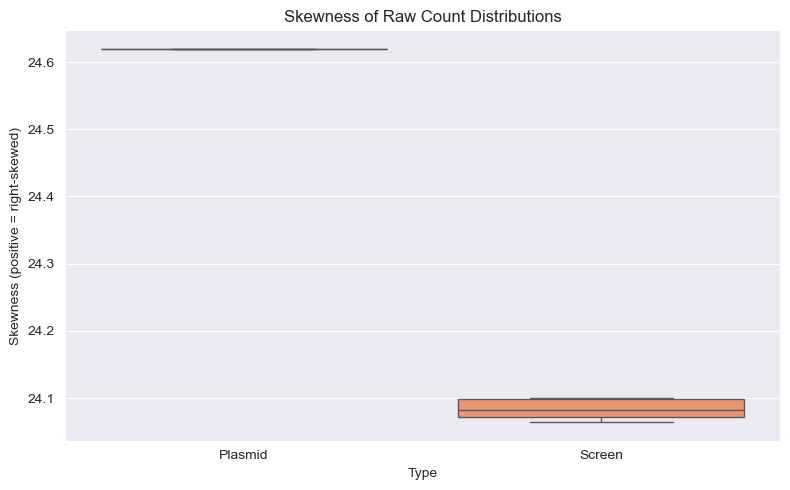

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Load raw counts
file_path = "/Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/analysis_quants/run_50401/deseq2_analysis/run_50401_all_counts.csv"
df = pd.read_csv(file_path)

# Identify columns
plasmid_cols = [col for col in df.columns if col.startswith("D0")]
screen_cols = [col for col in df.columns if col.startswith("D4") or col.startswith("D7") or col.startswith("D15")]

# Compute skewness
skew_data = {
    "Sample": plasmid_cols + screen_cols,
    "Skewness": [skew(df[col].dropna()) for col in plasmid_cols + screen_cols],
    "Type": ["Plasmid"] * len(plasmid_cols) + ["Screen"] * len(screen_cols)
}
skew_df = pd.DataFrame(skew_data)

# Print skewness values
print(skew_df)

# Plot distribution of skewness
plt.figure(figsize=(8, 5))
sns.boxplot(data=skew_df, x="Type", y="Skewness", palette="Set2")
plt.title("Skewness of Raw Count Distributions")
plt.ylabel("Skewness (positive = right-skewed)")
plt.tight_layout()
plt.show()


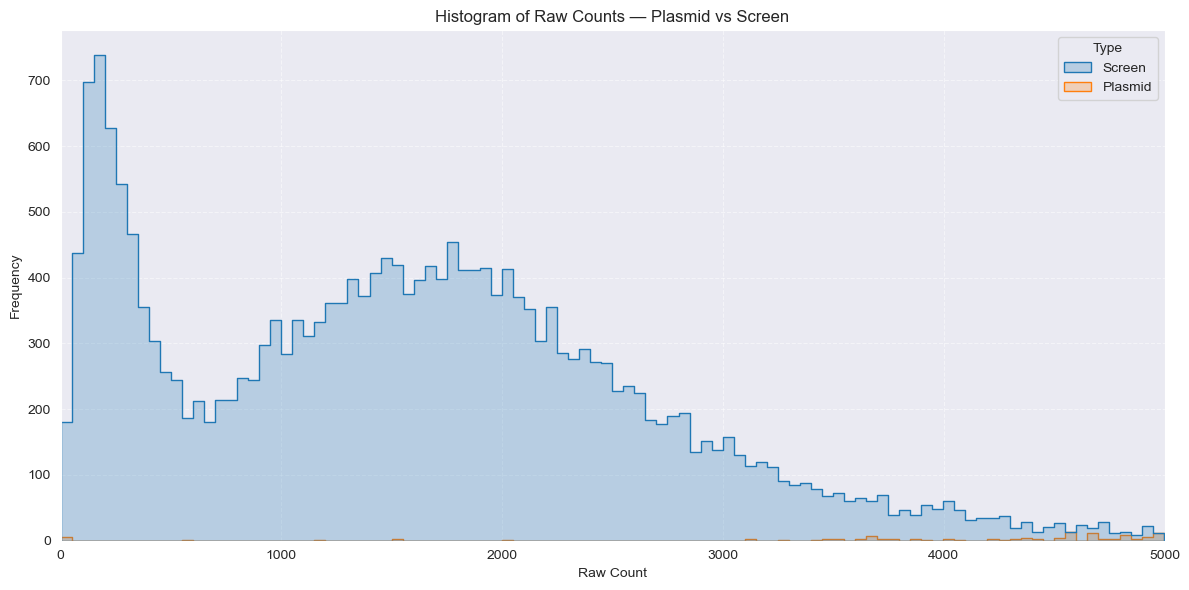

In [8]:
# Columns for plasmid and screen
plasmid_col = 'D0R1'
screen_cols = [col for col in df.columns if col.startswith(('D4', 'D7', 'D15'))]

# Melt screen data into long format
screen_long = df[screen_cols].melt(var_name='Screen_Sample', value_name='Raw_Count')
screen_long['Type'] = 'Screen'

# Melt plasmid data
plasmid_df = pd.DataFrame({ 'Raw_Count': df[plasmid_col] })
plasmid_df['Screen_Sample'] = plasmid_col
plasmid_df['Type'] = 'Plasmid'

# Combine
combined_df = pd.concat([screen_long, plasmid_df], ignore_index=True)

# Optional: remove extremely high values for better plot scaling
combined_df = combined_df[combined_df['Raw_Count'] < 5000]

# Plot histograms
plt.figure(figsize=(12, 6))
sns.histplot(data=combined_df, x='Raw_Count', hue='Type', element='step', common_norm=False, bins=100)
plt.title("Histogram of Raw Counts — Plasmid vs Screen")
plt.xlabel("Raw Count")
plt.ylabel("Frequency")
plt.xlim(0, 5000)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



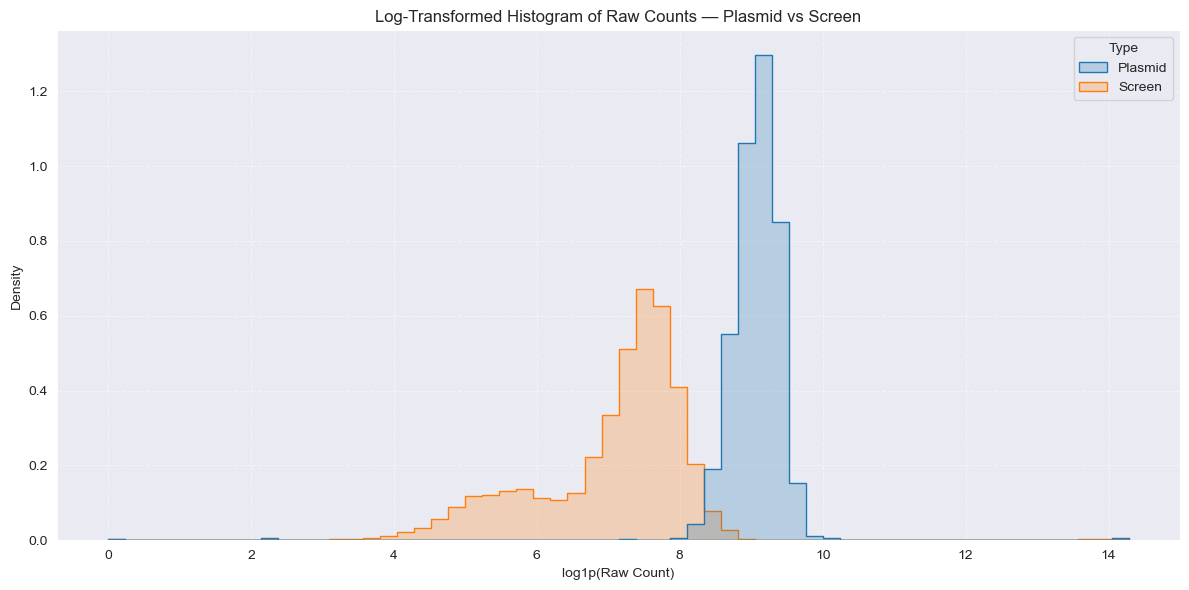

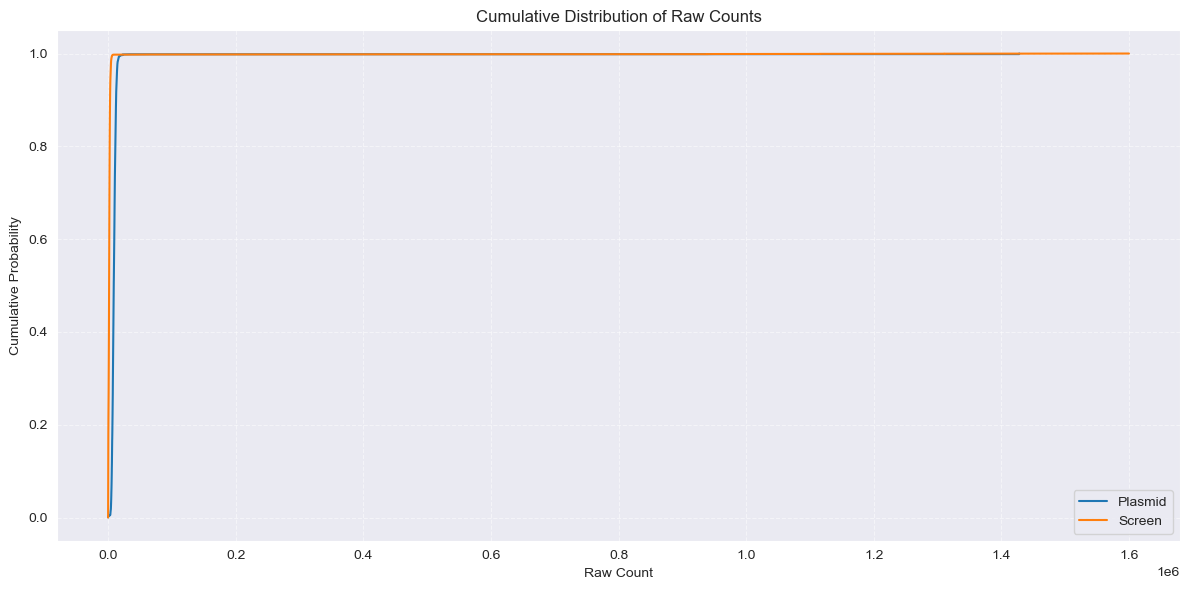

/var/folders/88/r4q5_g595xs0mq3119k4nxy40000gq/T/ipykernel_17524/3397951858.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x="Type", y=np.log1p(df_long["Count"]), palette="Set2")


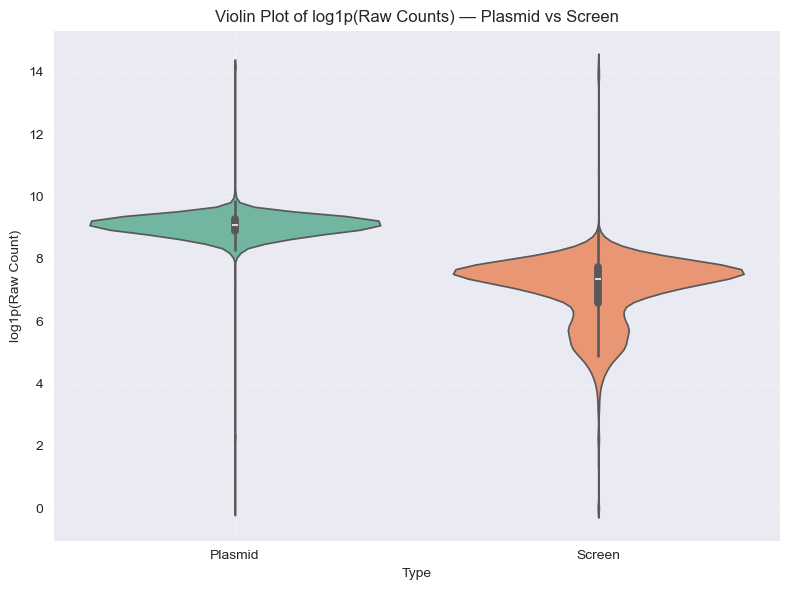

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the raw counts file
file_path = "/Users/ds39/Documents/Sunny/MAVE/MAVE_Rawdata/analysis_quants/run_50401/deseq2_analysis/run_50401_all_counts.csv"
df = pd.read_csv(file_path)

# Melt the dataframe into long format
df_long = df.melt(id_vars=["ID"] if "ID" in df.columns else None, var_name="Sample", value_name="Count")

# Label D0R1 as Plasmid, others as Screen
df_long["Type"] = df_long["Sample"].apply(lambda x: "Plasmid" if x == "D0R1" else "Screen")

# Log1p transformed histogram
plt.figure(figsize=(12, 6))
sns.histplot(data=df_long, x=np.log1p(df_long["Count"]), hue="Type", bins=60, element="step", stat="density", common_norm=False)
plt.title("Log-Transformed Histogram of Raw Counts — Plasmid vs Screen")
plt.xlabel("log1p(Raw Count)")
plt.ylabel("Density")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Cumulative distribution plot
plt.figure(figsize=(12, 6))
for sample_type in ["Plasmid", "Screen"]:
    subset = df_long[df_long["Type"] == sample_type]["Count"]
    sorted_vals = np.sort(subset)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    plt.plot(sorted_vals, cdf, label=sample_type)

plt.title("Cumulative Distribution of Raw Counts")
plt.xlabel("Raw Count")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_long, x="Type", y=np.log1p(df_long["Count"]), palette="Set2")
plt.title("Violin Plot of log1p(Raw Counts) — Plasmid vs Screen")
plt.ylabel("log1p(Raw Count)")
plt.xlabel("Type")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# Top 100 variants by count
top_plasmid = counts.sort_values(by=plasmid_col, ascending=False).head(100).index
top_screen = counts.sort_values(by="D4R1", ascending=False).head(100).index

# Overlap
overlap = len(set(top_plasmid).intersection(set(top_screen)))
print(f"Top 100 overlap: {overlap}/100")


Top 100 overlap: 33/100


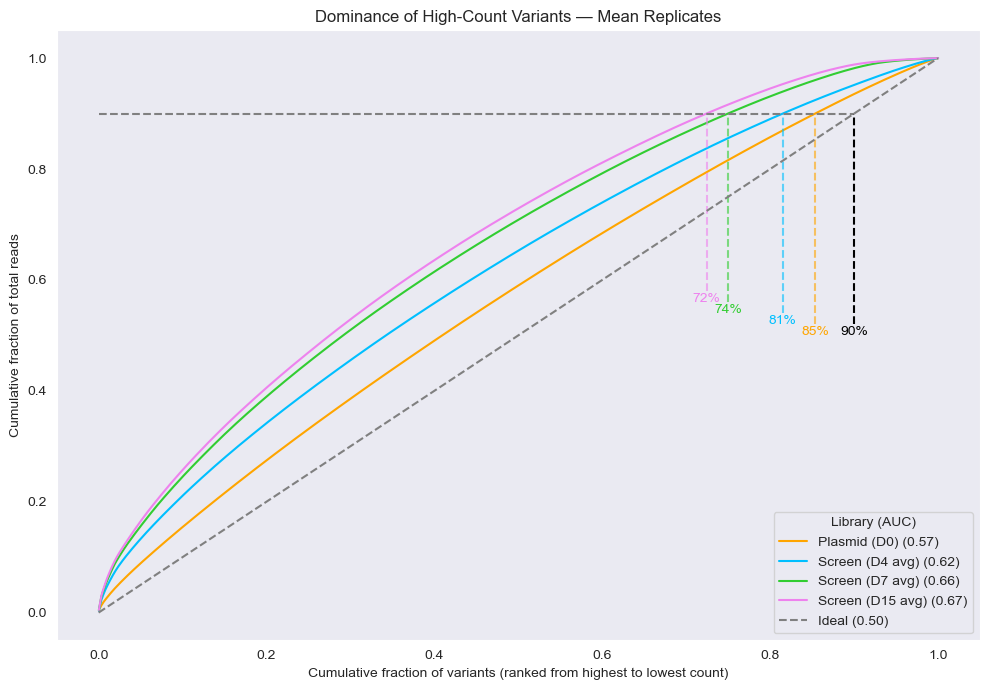

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load counts
df = pd.read_csv("/Users/ds39/Documents/Sunny/MAVE/RD_projects/Distribution_screw/Plasmids_screeningCounts/RSDC_all_counts.csv")


# Identify columns
plasmid_col = "D0R1"
d4_cols = [col for col in df.columns if col.startswith("D4")]
d7_cols = [col for col in df.columns if col.startswith("D7")]
d15_cols = [col for col in df.columns if col.startswith("D15")]

# Compute mean count
df["D4_mean"] = df[d4_cols].mean(axis=1)
df["D7_mean"] = df[d7_cols].mean(axis=1)
df["D15_mean"] = df[d15_cols].mean(axis=1)

# Setup plot
plt.figure(figsize=(10, 7))
curves = {
    "Plasmid (D0)": ("D0R1", "orange"),
    "Screen (D4 avg)": ("D4_mean", "deepskyblue"),
    "Screen (D7 avg)": ("D7_mean", "limegreen"),
    "Screen (D15 avg)": ("D15_mean", "violet")
}

for i, (label, (col, color)) in enumerate(curves.items()):
    sorted_counts = df[col].sort_values(ascending=False).reset_index(drop=True)
    cum_reads = sorted_counts.cumsum() / sorted_counts.sum()
    cum_variants = (np.arange(len(sorted_counts)) + 1) / len(sorted_counts)

    # Plot the curve
    auc = np.trapz(cum_reads, cum_variants)
    plt.plot(cum_variants, cum_reads, label=f"{label} ({auc:.2f})", color=color)

    # Mark vertical dashed line at 90% of reads
    idx_90 = np.argmax(cum_reads >= 0.9)
    x_90 = cum_variants[idx_90]
    y_bottom = 0.52 + i * 0.02
    plt.vlines(x_90, ymin=y_bottom, ymax=0.9, color=color, linestyle="--", alpha=0.6)
    plt.text(x_90, y_bottom - 0.02, f"{int(x_90*100)}%", color=color, ha="center", fontsize=10)

# Ideal diagonal
x = np.linspace(0, 1, 500)
plt.plot(x, x, color="gray", linestyle="--", label="Ideal (0.50)")

# Horizontal 90% line: limited to intersect vertical
plt.hlines(0.9, xmin=0.0, xmax=0.9, color="gray", linestyle="--")

# Vertical 90% line — now just like others (not to x-axis)
plt.vlines(0.9, ymin=0.52, ymax=0.9, color="black", linestyle="--")
plt.text(0.9, 0.52 - 0.02, "90%", color="black", ha="center", fontsize=10)

# Aesthetics
plt.xlabel("Cumulative fraction of variants (ranked from highest to lowest count)")
plt.ylabel("Cumulative fraction of total reads")
plt.title("Dominance of High-Count Variants — Mean Replicates")
plt.legend(title="Library (AUC)", loc="lower right")
plt.grid(False)
plt.tight_layout()
plt.show()

